# Payroll Analytics — 2023 to 2026
1200 rows · 25 employees · 4 years · 12 months

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('charts', exist_ok=True)

df = pd.read_csv('data/payroll_history.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1200, 10)


,emp_id,name,department,year,month,leaves,days_worked,hours_worked,hourly_rate,wage
0,1,abhinav,Engineering,2023,Jan,4,16,96,20.0,1920.0
1,1,abhinav,Engineering,2023,Feb,0,20,100,20.0,2000.0
2,1,abhinav,Engineering,2023,Mar,5,15,112,20.0,2240.0
3,1,abhinav,Engineering,2023,Apr,2,18,104,20.0,2080.0
4,1,abhinav,Engineering,2023,May,1,19,100,20.0,2000.0


In [2]:
print(df.dtypes)
print('\nNull values:')
print(df.isnull().sum())

emp_id            int64
name             object
department       object
year              int64
month            object
leaves            int64
days_worked       int64
hours_worked      int64
hourly_rate     float64
wage            float64
dtype: object

Null values:
emp_id          0
name            0
department      0
year            0
month           0
leaves          0
days_worked     0
hours_worked    0
hourly_rate     0
wage            0
dtype: int64


## Basic Stats (NumPy)

In [3]:
wages = df['wage'].values
print(f'Average wage  : ${np.mean(wages):.2f}')
print(f'Highest wage  : ${np.max(wages):.2f}')
print(f'Lowest wage   : ${np.min(wages):.2f}')
print(f'Std deviation : ${np.std(wages):.2f}')
print(f'Median wage   : ${np.median(wages):.2f}')

Average wage  : $2275.51
Highest wage  : $3704.00
Lowest wage   : $1200.00
Std deviation : $517.75
Median wage   : $2240.00


## Aggregations (Pandas groupby)

In [4]:
dept_avg = df.groupby('department')['wage'].mean().round(2).sort_values(ascending=False)
dept_avg

department
Marketing      2353.72
HR             2325.51
Finance        2308.15
Sales          2258.16
Engineering    2230.63
Name: wage, dtype: float64

In [5]:
year_avg = df.groupby('year')['wage'].mean().round(2)
year_avg

year
2023    2102.67
2024    2184.84
2025    2358.76
2026    2455.75
Name: wage, dtype: float64

In [6]:
top_earners = df.groupby('name')['wage'].sum().sort_values(ascending=False).head(5)
top_earners

name
sanjay    116296.4
nisha     115738.8
divya     113879.6
vikram    113464.0
kavya     112995.2
Name: wage, dtype: float64

In [7]:
dept_leaves = df.groupby('department')['leaves'].mean().round(2).sort_values(ascending=False)
dept_leaves

department
Sales          2.68
Finance        2.59
Marketing      2.51
Engineering    2.46
HR             2.33
Name: leaves, dtype: float64

In [8]:
pivot = df.pivot_table(values='wage', index='department', columns='year', aggfunc='mean').round(2)
pivot

year,2023,2024,2025,2026
department,,,,
Engineering,2056.67,2095.62,2352.00,2418.21
Finance,2073.33,2236.50,2381.40,2541.36
HR,2446.67,2163.00,2462.25,2230.12
Marketing,2166.67,2310.00,2432.85,2505.34
Sales,2103.81,2192.00,2300.55,2436.26


In [9]:
emp_summary = df.groupby(['name', 'department']).agg(
    total_wage=('wage', 'sum'),
    avg_monthly_wage=('wage', 'mean'),
    total_leaves=('leaves', 'sum'),
    total_hours=('hours_worked', 'sum')
).round(2).sort_values('total_wage', ascending=False)
emp_summary

,,total_wage,avg_monthly_wage,total_leaves,total_hours
name,department,,,,
sanjay,Finance,116296.4,2422.84,114,5388
nisha,Marketing,115738.8,2411.22,114,5380
divya,Marketing,113879.6,2372.49,125,5284
vikram,Finance,113464.0,2363.83,127,5260
kavya,Engineering,112995.2,2354.07,95,5244
manoj,Finance,112786.2,2349.71,125,5220
ram,HR,111624.4,2325.51,112,5200
sneha,Sales,110450.4,2301.05,121,5136
varun,Sales,110056.4,2292.84,154,5100


---
## Charts — Matplotlib + Seaborn

### Chart 1 — Avg Wage per Department (Matplotlib)

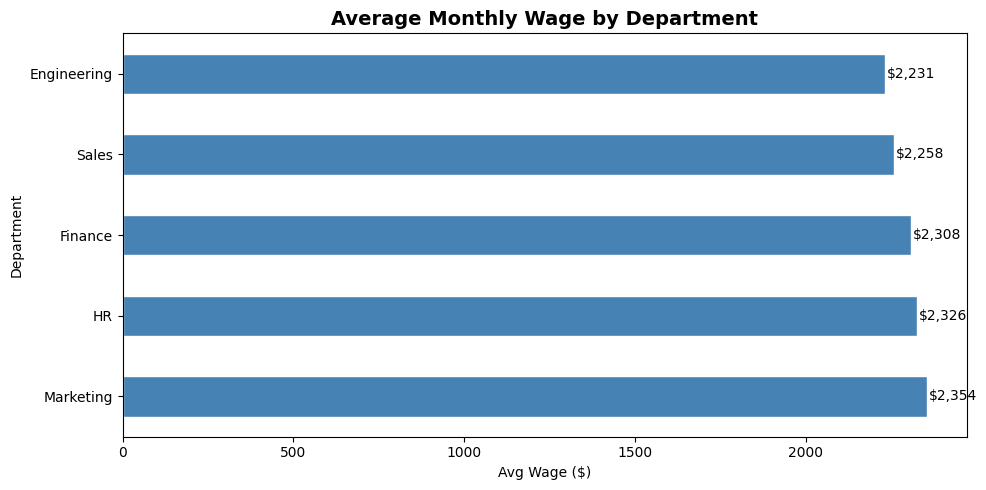

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
dept_avg.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average Monthly Wage by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Wage ($)')
ax.set_ylabel('Department')
for bar in ax.patches:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/dept_avg_wage.png', dpi=150)
plt.show()

### Chart 2 — Salary Trend by Year (Matplotlib)

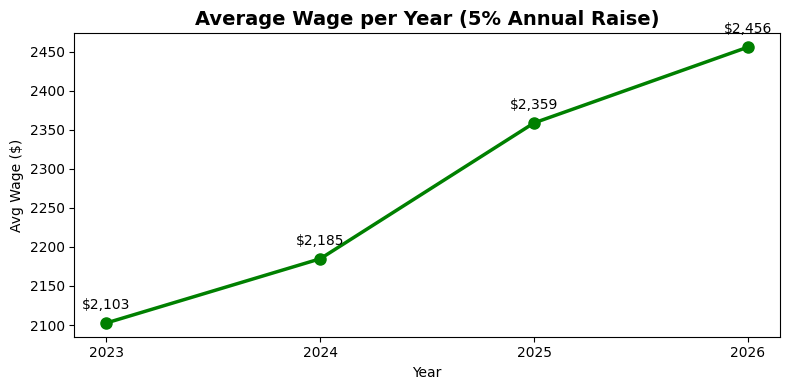

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
year_avg.plot(kind='line', ax=ax, marker='o', color='green', linewidth=2.5, markersize=8)
ax.set_title('Average Wage per Year (5% Annual Raise)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Wage ($)')
ax.set_xticks([2023, 2024, 2025, 2026])
for x, y in zip(year_avg.index, year_avg.values):
    ax.annotate(f'${y:,.0f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/salary_trend_by_year.png', dpi=150)
plt.show()

### Chart 3 — Dept x Year Grouped Bar (Matplotlib)

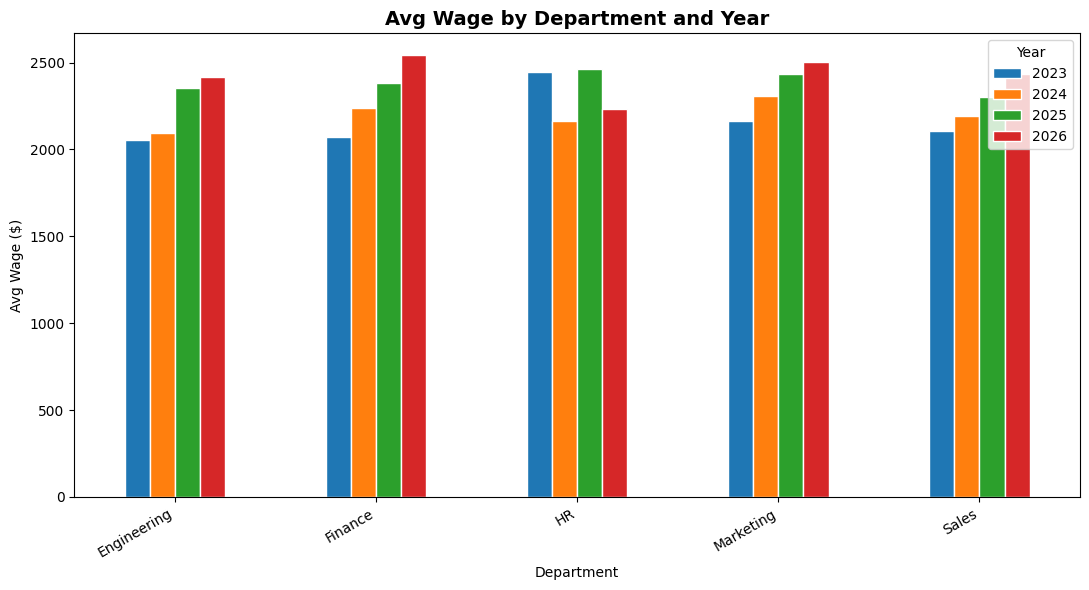

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Avg Wage by Department and Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Avg Wage ($)')
ax.set_xticklabels(pivot.index, rotation=30, ha='right')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('charts/dept_year_grouped_bar.png', dpi=150)
plt.show()

### Chart 4 — Wage Heatmap: Dept × Year (Seaborn)

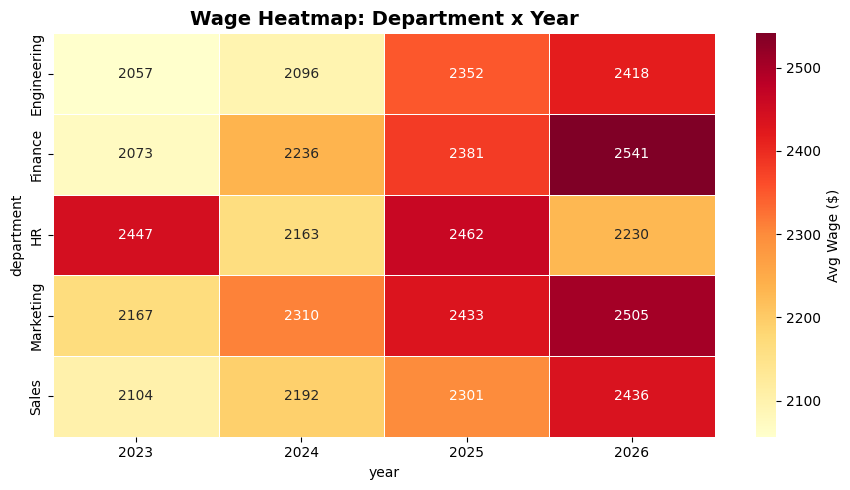

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Wage ($)'})
ax.set_title('Wage Heatmap: Department x Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/wage_heatmap.png', dpi=150)
plt.show()

### Chart 5 — Top 5 All-Time Earners (Seaborn)

C:\Users\ABHINAVVIKRAM\AppData\Local\Temp\ipykernel_22216\2370172954.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_earners.values, y=top_earners.index,


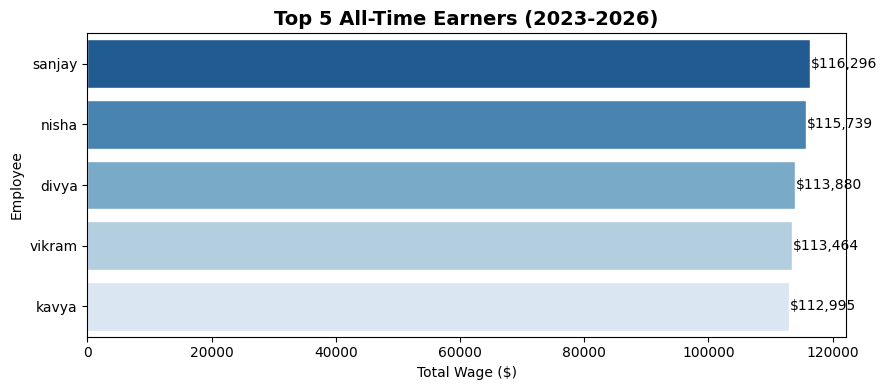

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=top_earners.values, y=top_earners.index,
            ax=ax, palette='Blues_r', edgecolor='white')
ax.set_title('Top 5 All-Time Earners (2023-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Wage ($)')
ax.set_ylabel('Employee')
for bar in ax.patches:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/top5_earners.png', dpi=150)
plt.show()